# Assignment 4

Anina Klaus

In [ ]:
# If working with colab: Installs
!pip install datasets
!pip install conllu
# !pip install transformers
!pip install livelossplot

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 521.2/521.2 kB 6.9 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 115.3/115.3 kB 10.0 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 134.8/134.8 kB 5.7 MB/s eta 0:00:00


Imports:

In [ ]:
import torch
from datasets import load_dataset
from transformers import XLMRobertaTokenizerFast, XLMRobertaModel
from torch.utils.data import DataLoader

from livelossplot import PlotLosses

In this task, I will be using the tokenization function as provided in the assignment description:

In [ ]:
def tokenize_and_align_labels(examples, label_all_tokens=False, skip_index=-100):
    tokenized_inputs = tokenizer(examples["tokens"], truncation=True, is_split_into_words=True, padding=True)
    labels = []

    for i, label in enumerate(examples["upos"]):
        word_ids = tokenized_inputs.word_ids(batch_index=i)
        previous_word_idx = None
        label_ids : list[int] = []
        for word_idx in word_ids:
            # Special tokens have a word id that is None. We set the label to -100 so they are automatically
            # ignored in the loss function.
            if word_idx is None:
                label_ids.append(skip_index)

            # We set the label for the first token of each word.
            elif word_idx != previous_word_idx:
                label_ids.append(label[word_idx])

            # For the other tokens in a word, we set the label to either the current label or -100, depending on
            # the label_all_tokens flag.
            else:
                label_ids.append(label[word_idx] if label_all_tokens else skip_index)

            previous_word_idx = word_idx

        labels.append(label_ids)

    tokenized_inputs["labels"] = labels
    return tokenized_inputs

This tokenization function relies on a global variable named "tokenizer", which is set up in the following cell with the XLMRobertaTokenizer.

In [ ]:
tokenizer = XLMRobertaTokenizerFast.from_pretrained("xlm-roberta-base")

sentencepiece.bpe.model:   0%|          | 0.00/5.07M [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/9.10M [00:00<?, ?B/s]

config.json:   0%|          | 0.00/615 [00:00<?, ?B/s]

If GPU training is available, the device is selected accordingly in the following cell:

In [ ]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
device

device(type='cuda')

For subsequent dataset preparation, the batch siz will already be set up here, with a value of 16 items per batch.

In [ ]:
BATCH_SIZE = 16

## Dataset preparation

In the following cell, the corpus is prepared for training and testing.

In [ ]:
# Load dataset
ds = load_dataset("universal_dependencies", name="de_gsd")
train, val, test = ds.values()

# Tokenize
train_tokenized = train.map(lambda example: tokenize_and_align_labels(example),
                            batched=True, batch_size=BATCH_SIZE)

val_tokenized = val.map(lambda example: tokenize_and_align_labels(example),
                        batched=True, batch_size=BATCH_SIZE)

# Filter as needed for subsequent processing
train_tokenized.set_format(type='torch', columns=list(["input_ids",
                                                       "labels",
                                                       "attention_mask"]))
val_tokenized.set_format(type='torch', columns=list(["input_ids",
                                                     "labels",
                                                     "attention_mask"]))

# Create DataLoaders
train_dataloader = DataLoader(train_tokenized, batch_size=BATCH_SIZE)
val_dataloader = DataLoader(val_tokenized, batch_size=BATCH_SIZE)

Extracting data files:   0%|          | 0/3 [00:00<?, ?it/s]

Generating train split:   0%|          | 0/13814 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/799 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/977 [00:00<?, ? examples/s]

Map:   0%|          | 0/13814 [00:00<?, ? examples/s]

Map:   0%|          | 0/799 [00:00<?, ? examples/s]

A quick look at the data tells us that the trainig set consists of 13,814 sentences, the validation set of 799 sentences and the test set of 977 sentences. The sets contain a number of features, but to our task at hand only "tokens" and "upos" will be relevant.

In [ ]:
print(train)
print(val)
print(test)

Dataset({
    features: ['idx', 'text', 'tokens', 'lemmas', 'upos', 'xpos', 'feats', 'head', 'deprel', 'deps', 'misc'],
    num_rows: 13814
})
Dataset({
    features: ['idx', 'text', 'tokens', 'lemmas', 'upos', 'xpos', 'feats', 'head', 'deprel', 'deps', 'misc'],
    num_rows: 799
})
Dataset({
    features: ['idx', 'text', 'tokens', 'lemmas', 'upos', 'xpos', 'feats', 'head', 'deprel', 'deps', 'misc'],
    num_rows: 977
})


### The tag set

The POS tags are to be found the "upos" feature of the dataset. They are, however, encoded as tag indices. The following function returns a dictionary to map them back.

In [ ]:
def get_mapping(examples):
    """Get mapping of tag indices to human-readable tags."""
    upos = examples.features["upos"].feature
    # Return as dicitonary
    return {i: upos.int2str(i) for i in range(len(upos.names))}

In [ ]:
tag_mapping = get_mapping(train)
print(tag_mapping)
print("Number of possible tags:", len(tag_mapping.keys()))
print("Possible tags:", list(tag_mapping.values()))

{0: 'NOUN', 1: 'PUNCT', 2: 'ADP', 3: 'NUM', 4: 'SYM', 5: 'SCONJ', 6: 'ADJ', 7: 'PART', 8: 'DET', 9: 'CCONJ', 10: 'PROPN', 11: 'PRON', 12: 'X', 13: '_', 14: 'ADV', 15: 'INTJ', 16: 'VERB', 17: 'AUX'}
Number of possible tags: 18
Possible tags: ['NOUN', 'PUNCT', 'ADP', 'NUM', 'SYM', 'SCONJ', 'ADJ', 'PART', 'DET', 'CCONJ', 'PROPN', 'PRON', 'X', '_', 'ADV', 'INTJ', 'VERB', 'AUX']


With this, we can now further inspect our dataset by looking at some tag sequences for sentences from the dataset:

In [ ]:
# Look at first 5 sentences
for i in range(5):
    sent = train[i]
    print("Sentence:", sent["text"])
    for token, tag_id in zip(sent["tokens"], sent["upos"]):
        print(tag_mapping[tag_id], "\t", token)
    print("-"*50)

Sentence: Sehr gute Beratung, schnelle Behebung der Probleme, so stelle ich mir Kundenservice vor.
ADV 	 Sehr
ADJ 	 gute
NOUN 	 Beratung
PUNCT 	 ,
ADJ 	 schnelle
NOUN 	 Behebung
DET 	 der
NOUN 	 Probleme
PUNCT 	 ,
ADV 	 so
VERB 	 stelle
PRON 	 ich
PRON 	 mir
NOUN 	 Kundenservice
ADP 	 vor
PUNCT 	 .
--------------------------------------------------
Sentence: Die Kosten sind definitiv auch im Rahmen.
DET 	 Die
NOUN 	 Kosten
VERB 	 sind
ADV 	 definitiv
ADV 	 auch
_ 	 im
ADP 	 in
DET 	 dem
NOUN 	 Rahmen
PUNCT 	 .
--------------------------------------------------
Sentence: Nette Gespräche, klasse Ergebnis
ADJ 	 Nette
NOUN 	 Gespräche
PUNCT 	 ,
ADJ 	 klasse
NOUN 	 Ergebnis
--------------------------------------------------
Sentence: Ich bin seit längerer Zeit zur Behandlung verschiedenster "Leiden" in der Physiotherapieraxis "Gaby Montag" im Vital Center und kann ausschließlich Positives berichten!
PRON 	 Ich
VERB 	 bin
ADP 	 seit
ADJ 	 längerer
NOUN 	 Zeit
_ 	 zur
ADP 	 zu
DET 	 der
NOUN 

## Setting up the network

The following class provides the neural network for classification into the 18 tag classes:

In [ ]:
class POSTagger(torch.nn.Module):
    """Set up neural network for POS tagging.

    This network consists of two layers: one RoBERTa embedding layer and on top
    of that a linear layer for classification. The linear layer projects to the
    final set of classes.

    Args:
        num_classes (int): the number of classes
    """
    def __init__(self, num_classes):
        super(POSTagger, self).__init__()
        self.roberta_embedding = XLMRobertaModel.from_pretrained("xlm-roberta-base")
        self.softmax = torch.nn.Softmax(dim=1)
        self.linear = torch.nn.Linear(768, num_classes)

    def forward(self, x, y):
        # Retrieve embedding representation first
        emb = self.roberta_embedding(x, attention_mask=y).last_hidden_state
        # Feed through single linear layer
        return self.linear(emb)

As only the final linear layer is to be trained, all other (empedding) layers are frozen. With the network set up as shown above, they can be identified by their names, which will start with "roberta".

In [ ]:
# Set up neural network
num_classes = len(tag_mapping)
print("Number of possible classes:", num_classes)
tag_nn = POSTagger(num_classes)

for name, params in tag_nn.named_parameters():
    # Freeze embedding layers
    if name.startswith("roberta"):
        params.requires_grad = False

# Moving the model to the right device:
tag_nn.to(device)

Number of possible classes: 18


POSTagger(
  (roberta_embedding): XLMRobertaModel(
    (embeddings): XLMRobertaEmbeddings(
      (word_embeddings): Embedding(250002, 768, padding_idx=1)
      (position_embeddings): Embedding(514, 768, padding_idx=1)
      (token_type_embeddings): Embedding(1, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (encoder): XLMRobertaEncoder(
      (layer): ModuleList(
        (0-11): 12 x XLMRobertaLayer(
          (attention): XLMRobertaAttention(
            (self): XLMRobertaSelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=True)
              (key): Linear(in_features=768, out_features=768, bias=True)
              (value): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.1, inplace=False)
            )
            (output): XLMRobertaSelfOutput(
              (dense): Linear(in_features=768, out_features=768, bias=True)
    

This is what a feed-forward pass through the network will look like:

In [ ]:
# Set up softmax (as the network itself will return raw activations)
softmax = torch.nn.Softmax(dim=1)

# Retrieve batch
first_batch = next(iter(train_dataloader))

# Get predictions for batch
inputs = first_batch["input_ids"].to(device)
attention_mask = first_batch["attention_mask"].to(device)
pred_raw = tag_nn(inputs, attention_mask)
softmaxed_pred = softmax(pred_raw)
# Show results
print(softmaxed_pred)

tensor([[[0.0208, 0.0260, 0.0141,  ..., 0.0160, 0.0148, 0.0187],
         [0.0181, 0.0167, 0.0192,  ..., 0.0182, 0.0177, 0.0181],
         [0.0191, 0.0174, 0.0201,  ..., 0.0199, 0.0178, 0.0176],
         ...,
         [0.0174, 0.0176, 0.0171,  ..., 0.0173, 0.0181, 0.0182],
         [0.0174, 0.0176, 0.0171,  ..., 0.0173, 0.0181, 0.0182],
         [0.0174, 0.0176, 0.0171,  ..., 0.0173, 0.0181, 0.0182]],

        [[0.0201, 0.0227, 0.0158,  ..., 0.0170, 0.0162, 0.0191],
         [0.0178, 0.0166, 0.0200,  ..., 0.0206, 0.0188, 0.0186],
         [0.0181, 0.0164, 0.0208,  ..., 0.0206, 0.0192, 0.0170],
         ...,
         [0.0176, 0.0179, 0.0174,  ..., 0.0174, 0.0176, 0.0178],
         [0.0176, 0.0179, 0.0174,  ..., 0.0174, 0.0176, 0.0178],
         [0.0176, 0.0179, 0.0174,  ..., 0.0174, 0.0176, 0.0178]],

        [[0.0184, 0.0190, 0.0172,  ..., 0.0174, 0.0174, 0.0183],
         [0.0180, 0.0153, 0.0203,  ..., 0.0189, 0.0180, 0.0159],
         [0.0181, 0.0160, 0.0186,  ..., 0.0198, 0.0191, 0.

## Training

### Setup

For monitoring during training and subsequent evaluation, the accuracy will have to be calculated. The following function will be used for that:

In [ ]:
def accuracy(gold, pred, ignore_index=-100):
    """Calculate the accuracy for a given set of predictions."""
    # List containing 1 for each correct prediction, 0 for each incorrect one
    filtered_preds = [int(g == p) for g, p in zip(gold, pred) if g != -100]
    # (correct, total)
    return sum(filtered_preds), len(filtered_preds)

The rest of the hyperparameters will also have to be set now. Batch size was already definied when creating the data loaders.

In [ ]:
LEARNING_RATE = 0.0015
NUM_EPOCHS = 5

The Adam optimizer will be used during training, together with the cross-entropy loss measure.

In [ ]:
optimizer = torch.optim.Adam(
    tag_nn.parameters(),
    lr=LEARNING_RATE
)
loss_function = torch.nn.CrossEntropyLoss(ignore_index=-100)

To avoid code duplication, the feed-forward passes and calculations of loss and counts for the accuracy calculation are moved to the following function:

In [ ]:
def get_pred_metrics(model, batch, device):
    """Get all necessary metrics for one forward pass of a batch.

    These include: batch loss, number of correct predictions and total count
    of items in this batch
    """
    inputs = batch["input_ids"].to(device)
    attention_mask = batch["attention_mask"].to(device)
    # Get prediction
    pred = model(inputs, attention_mask)
    pred = pred.flatten(end_dim=1)
    # Get gold labels
    gold_labels = batch["labels"].to(device)
    gold_labels = gold_labels.flatten(end_dim=1)
    # Calculate loss
    batch_loss = loss_function(pred, gold_labels)
    # Calculate accuracy, get loss
    pred = torch.argmax(pred, dim=1)
    batch_correct, batch_total = accuracy(gold_labels, pred)
    return batch_loss, batch_correct, batch_total

With this set-up, everything is ready for training of the network. The library *livelossplots* will help with monitoring of the training process by creating plotting the learning curves, updating the image for every epoch. The final plots for the learning process over all epochs will also be handed in with this assignment.

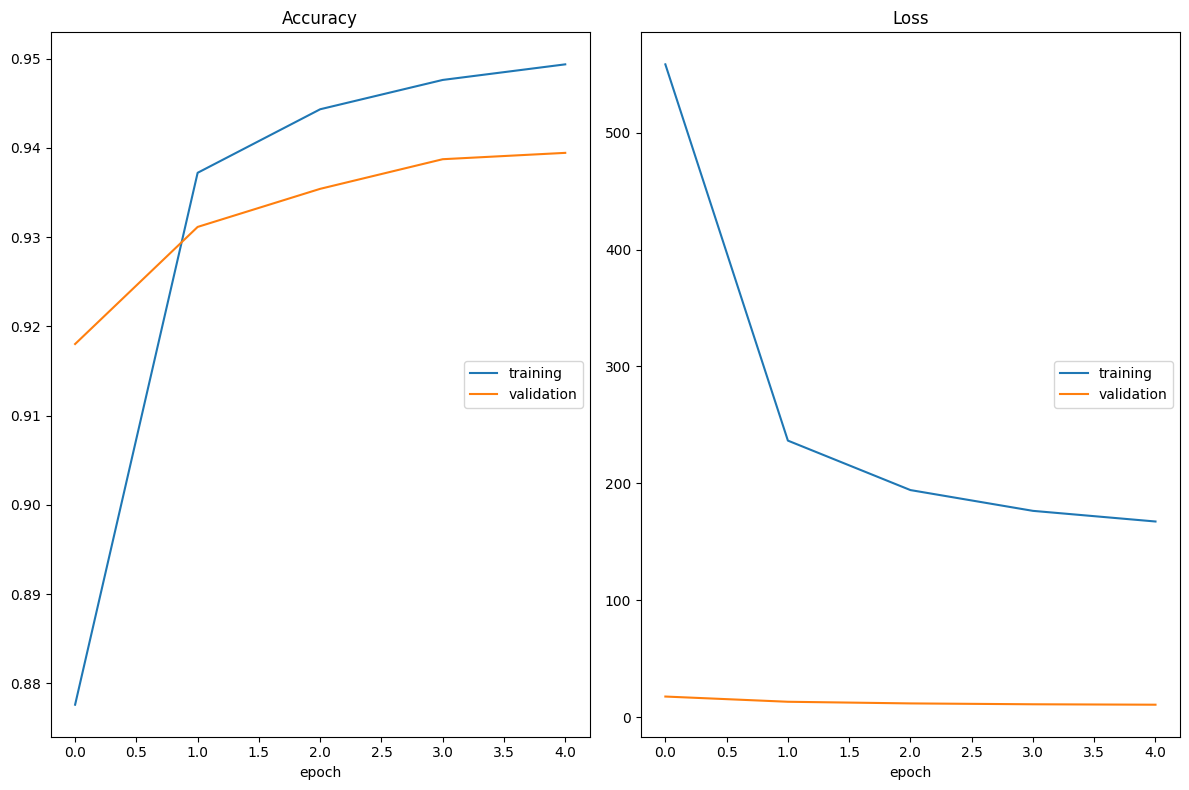

Accuracy
	training         	 (min:    0.878, max:    0.949, cur:    0.949)
	validation       	 (min:    0.918, max:    0.939, cur:    0.939)
Loss
	training         	 (min:  167.348, max:  558.413, cur:  167.348)
	validation       	 (min:   10.629, max:   17.610, cur:   10.629)


In [ ]:
liveloss = PlotLosses()  # Live loss plotting
logs = []
# Training loop
for epoch in range(NUM_EPOCHS):
    # Set model into training mode
    tag_nn.train()
    # Initialize counter
    train_total = 0
    train_correct = 0
    train_loss = 0
    # Work through batches
    for batch in train_dataloader:
        # Feed forward, get loss and counts for accuracy calculation
        batch_loss, batch_correct, batch_total = get_pred_metrics(tag_nn,
                                                                  batch,
                                                                  device)
        train_total += batch_total
        train_correct += batch_correct
        train_loss += batch_loss.item()
        # Update step
        optimizer.zero_grad()
        batch_loss.backward()
        optimizer.step()
    train_accuracy = train_correct / train_total
    # Testing on validation set
    with torch.no_grad():
        # Set model into evaldation mode
        tag_nn.eval()
        # Initialiize counter
        val_total = 0
        val_correct = 0
        val_loss = 0
        for batch in val_dataloader:
            # Get loss and counts for accuracy calculation
            batch_loss, batch_correct, batch_total = get_pred_metrics(tag_nn,
                                                                      batch,
                                                                      device)
            val_loss += batch_loss.item()
            val_total += batch_total
            val_correct += batch_correct
        val_accuracy = val_correct / val_total
    # Update plot
    epoch_results = {"Loss": train_loss,
                     "Accuracy": train_accuracy,
                     "val_Loss": val_loss,
                     "val_Accuracy": val_accuracy}
    logs.append(epoch_results)
    liveloss.update(epoch_results)
    liveloss.send()


As can be seen in the plots, the model learns to tokenize correctly pretty quickly. Interestingly, the loss on the validation set is very low. A picture like this would indicate a simpler validation set. The reduction method of the loss function should be "mean" by default. In terms of accuracy, the results on the two sets are not quite as far apart. The validation accuracy starts off higher, but the model has also already gone through its first update step at this point.

## Evaluation

Here are the results on the train and validation set during training:

In [ ]:
for epoch_results in logs:
    for key, value in epoch_results.items():
        print(f"{key}: {value:.4f}")
    print("-"*50)

Loss: 558.4131
Accuracy: 0.8776
val_Loss: 17.6095
val_Accuracy: 0.9180
--------------------------------------------------
Loss: 236.5442
Accuracy: 0.9372
val_Loss: 13.1439
val_Accuracy: 0.9311
--------------------------------------------------
Loss: 194.2320
Accuracy: 0.9443
val_Loss: 11.7347
val_Accuracy: 0.9354
--------------------------------------------------
Loss: 176.4542
Accuracy: 0.9476
val_Loss: 10.9932
val_Accuracy: 0.9387
--------------------------------------------------
Loss: 167.3483
Accuracy: 0.9494
val_Loss: 10.6291
val_Accuracy: 0.9394
--------------------------------------------------


Results on test set:

In [ ]:
# Tokenize
test_tokenized = test.map(lambda example: tokenize_and_align_labels(example),
                          batched=True, batch_size=BATCH_SIZE)

# Filter as needed for subsequent processing
test_tokenized.set_format(type='torch', columns=list(["input_ids",
                                                      "labels",
                                                      "attention_mask"]))

# Create DataLoaders
test_dataloader = DataLoader(test_tokenized, batch_size=BATCH_SIZE)

Map:   0%|          | 0/977 [00:00<?, ? examples/s]

In [ ]:
test_total = 0
test_correct = 0
test_loss = 0
with torch.no_grad():
    for batch in test_dataloader:
        # Get loss and counts for accuracy calculation
        batch_loss, batch_correct, batch_total = get_pred_metrics(tag_nn,
                                                                batch,
                                                                device)
        test_loss += batch_loss.item()
        test_total += batch_total
        test_correct += batch_correct
test_accuracy = test_correct / test_total
test_accuracy

0.9377533985213451

The HMM POS tagger reached an accuracy of 90.14% on the Universal GSD test set. While not a huge difference, the RoBERTa tagger with its 93.77% is still noticably better. It has the advantage of greater context-incorporation ability, which might explain this difference. The set-up with the added linear layer might also be better fit to deal with weighting different factors encoded in the embedding which are indicative of the correct tag choice. As for the HMM, these factors are limited to transition and emission probabilites. The RoBERTa embeddings might encode other usefull information like position in the sentence as well.

A drawback of the neural network setup is the ressources it requires in training, in either time or compute. The HMM, in contrast, is a very light-weight model. It also comes with the advantage of easier interpretability.